<a href="https://colab.research.google.com/github/SujalSP/Volatility-Pulse-Graph-using-python/blob/main/volatility_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

!pip install yfinance arch pandas matplotlib numpy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model

In [7]:
data = yf.download("RELIANCE.NS", start="2018-01-01", end="2024-01-01")

print(data.head())

/tmp/ipykernel_449/1721949307.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2018-01-01  401.864777  407.585177  400.870881  407.585177     9453202
2018-01-02  402.483246  406.193799  400.385024  403.300454     9499419
2018-01-03  404.095581  409.042975  403.322544  408.601227    13507800
2018-01-04  406.525055  407.187662  404.493091  405.575331     9008932
2018-01-05  407.828186  409.440517  406.503001  407.187694     7441284


In [9]:
data['returns'] = data['Close'].pct_change()

returns = data['returns'].dropna()

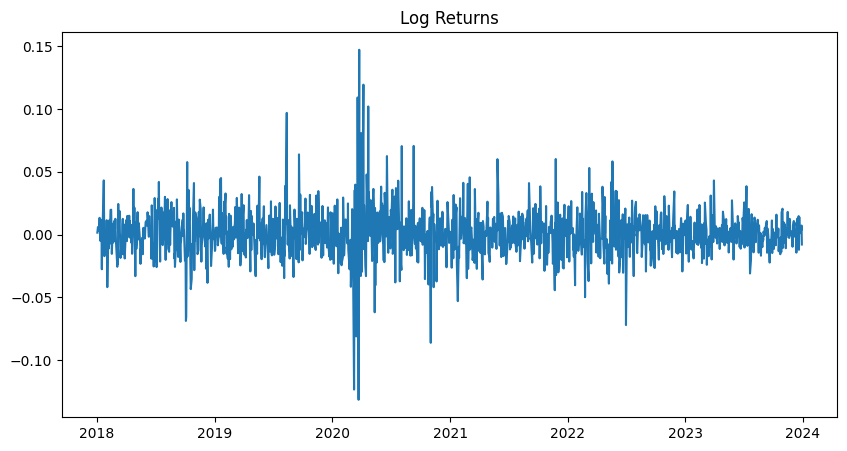

In [10]:
plt.figure(figsize=(10,5))
plt.plot(returns)
plt.title("Log Returns")
plt.show()

In [12]:
# 4️⃣ Fit GARCH(1,1) model
model = arch_model(returns*100, vol='Garch', p=1, q=1)

results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 8669.913126986743
Iteration:      2,   Func. Count:     16,   Neg. LLF: 15173.515324337735
Iteration:      3,   Func. Count:     24,   Neg. LLF: 4456.66999408893
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3355.816867626204
Iteration:      5,   Func. Count:     38,   Neg. LLF: 2866.5686758491684
Iteration:      6,   Func. Count:     44,   Neg. LLF: 2859.8625763232167
Iteration:      7,   Func. Count:     49,   Neg. LLF: 2859.8625632881526
Iteration:      8,   Func. Count:     54,   Neg. LLF: 2859.862561359988
Iteration:      9,   Func. Count:     58,   Neg. LLF: 2859.862561360197
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2859.862561359988
            Iterations: 9
            Function evaluations: 58
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:             

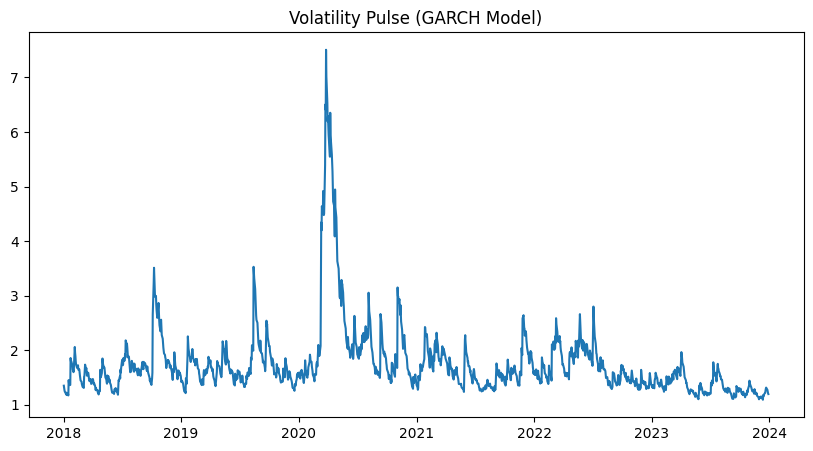

In [13]:
# 6️⃣ Extract conditional volatility
volatility = results.conditional_volatility


# 7️⃣ Plot volatility pulse graph
plt.figure(figsize=(10,5))
plt.plot(volatility)
plt.title("Volatility Pulse (GARCH Model)")
plt.show()